# Optimized Heart Disease Prediction

This notebook builds an optimized heart disease prediction model using the `heart.csv` dataset. It utilizes `StandardScaler` for feature scaling, `SMOTE` to balance the dataset, and a hyperparameter-tuned `LogisticRegression` model to improve prediction performance.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# Set plotting style
sns.set_theme(style="whitegrid")

### 1. Data Preprocessing & Scaling
We encode categorical variables and scale numerical variables. Scaling is important here because Logistic Regression performs better when features are on a similar scale, and SMOTE also benefits from properly scaled features.

In [12]:
# Load the dataset
df = pd.read_csv('heart.csv')

# Perform One-Hot Encoding
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate features and target
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale all features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Display processed shapes
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (734, 15)
Testing feature shape: (184, 15)
Training target shape: (734,)
Testing target shape: (184,)


### 2. Apply SMOTE to Balance the Training Data
With our features scaled, we can now generate synthetic data to balance the minority class in the training set.

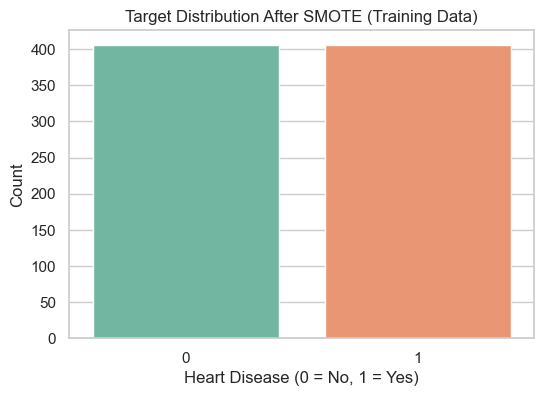

In [13]:
# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Display the class distribution after SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(
    x=y_train_smote,
    hue=y_train_smote,
    palette='Set2',
    legend=False
)
plt.title('Target Distribution After SMOTE (Training Data)')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

### 3. Train Optimized Logistic Regression
We use `GridSearchCV` to test multiple hyperparameter combinations and find the best Logistic Regression model for our balanced training data.

In [14]:
# Initialize Logistic Regression
lr = LogisticRegression(random_state=42)

# Define hyperparameter grid
param_grid = [
    {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'max_iter': [200, 500, 1000],
        'class_weight': [None, 'balanced']
    },
    {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs'],
        'penalty': ['l2'],
        'max_iter': [200, 500, 1000],
        'class_weight': [None, 'balanced']
    }
]

print("Tuning model hyperparameters... This may take a moment.")

# Perform grid search
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_smote, y_train_smote)

# Get the best model
best_model = grid_search.best_estimator_

# Print best results
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Tuning model hyperparameters... This may take a moment.
Best Parameters: {'C': 0.01, 'class_weight': None, 'max_iter': 200, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.8533742331288343


### 4. Evaluation and Visualizations
Let's see how the optimized Logistic Regression model performs on the unseen test set.

Training Accuracy: 0.8559
Testing Accuracy: 0.8913

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



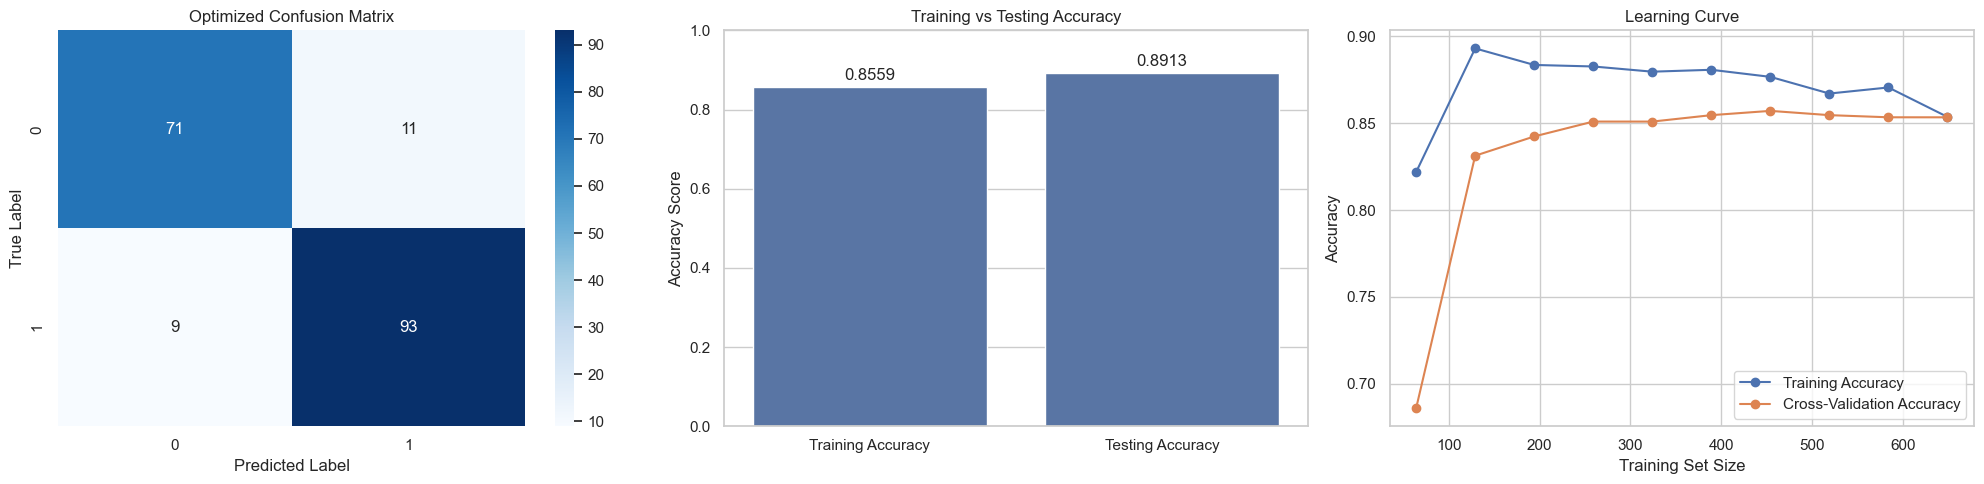

In [15]:
# Make predictions for both training and testing sets
y_train_pred = best_model.predict(X_train_smote)
y_test_pred = best_model.predict(X_test)

# Calculate training and testing accuracy
train_accuracy = accuracy_score(y_train_smote, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_test_pred))

# Set up the plotting area
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

# 1. Confusion Matrix Graph
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Optimized Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# 2. Training and Testing Accuracy Bar Chart
sns.barplot(
    x=['Training Accuracy', 'Testing Accuracy'],
    y=[train_accuracy, test_accuracy],
    ax=ax[1]
)
ax[1].set_ylim(0, 1)
ax[1].set_title('Training vs Testing Accuracy')
ax[1].set_ylabel('Accuracy Score')

# Add values above bars
ax[1].text(0, train_accuracy + 0.02, f'{train_accuracy:.4f}', ha='center', fontsize=12)
ax[1].text(1, test_accuracy + 0.02, f'{test_accuracy:.4f}', ha='center', fontsize=12)

# 3. Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_model,
    X=X_train_smote,
    y=y_train_smote,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

ax[2].plot(train_sizes, train_scores_mean, marker='o', label='Training Accuracy')
ax[2].plot(train_sizes, test_scores_mean, marker='o', label='Cross-Validation Accuracy')
ax[2].set_title('Learning Curve')
ax[2].set_xlabel('Training Set Size')
ax[2].set_ylabel('Accuracy')
ax[2].legend()
ax[2].grid(True)

plt.tight_layout()
plt.show()